In [1]:
import ast
import os
import pandas as pd

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


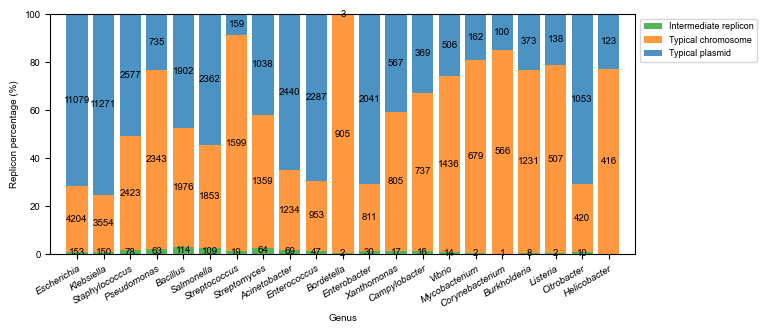

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager

font_path = "/usr/share/fonts/myFonts/arial.ttf"
ifont_path = "/usr/share/fonts/myFonts/ariali.ttf"

fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
fontManager.addfont(ifont_path)
ifont_prop = FontProperties(fname=ifont_path)
ifont_name = ifont_prop.get_name()

plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

italic_font = FontProperties(fname=ifont_path)
normal_font = FontProperties(fname=font_path)
legend_font = FontProperties(fname=ifont_path, size=7)
title_font = FontProperties(fname=ifont_path, size=8)

label = 'pident_90'
base_folder = '/active-data/analysis_results/chr_pla/genus'
all_counts = {}

for genus_name in keep_genus:
    folder = f'{base_folder}/statistics_records/{genus_name}'
    os.chdir(folder)
    csv_path = 'replicon-plasmid_fraction-self_bitscore_statistics.csv'
    
    fraction_data = pd.read_csv(csv_path)
    col_name = f'category-{label}'
    
    count_series = fraction_data[col_name].value_counts()
    all_counts[genus_name] = count_series

df_plot = pd.DataFrame(all_counts).T.fillna(0).astype(int)
df_percent = df_plot.div(df_plot.sum(axis=1), axis=0) * 100

fig = plt.figure(figsize=(7.5, 7.5))
ax = fig.add_axes([0.06, 0.68, 1-0.22, 0.32])
categories = df_plot.columns
colors = [plt.cm.tab10.colors[2], plt.cm.tab10.colors[1], plt.cm.tab10.colors[0], ]

bottom = np.zeros(len(df_plot))
for i, cat in enumerate(categories):
    ax.bar(
        df_plot.index,
        df_percent[cat],
        bottom=bottom,
        label=cat.capitalize(),
        color=colors[i],
        edgecolor='white',
        linewidth=0,
        alpha=0.8
    )
    
    for x_idx, num in enumerate(df_plot[cat]):
        pct = df_percent[cat].iloc[x_idx]
        if num > 0:
            ax.text(
                x_idx,
                bottom[x_idx] + pct/2,
                str(num),
                ha='center', va='center',
            )
    
    bottom += df_percent[cat].values

ax.set_xlim(-1, len(df_percent))
ax.set_ylim(0, 100)
ax.set_ylabel(f'Replicon percentage (%)')
ax.set_xlabel('Genus')
ax.tick_params(axis='x', labelrotation=30)
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor', fontproperties=legend_font)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.chdir(figure_fold)
plt.savefig(f"S_all_genera_replicon_percentage.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"S_all_genera_replicon_percentage.png", dpi=1000, bbox_inches="tight", transparent=True)

plt.show()